In [27]:
import pickle
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import eelbrain
from eelbrain import combine


In [ ]:
# Make sure your environment is set up (conda activate eelbrain-env and source musical-surprisal/TRF/.venv/bin/activate)

# ! python experiments/TRF_sklearn.py
# ! python experiments/TRF_boosting.py
# ! python experiments/TRF_mne.py
# ! python experiments/TRF_conv_2_windowed.py

In [ ]:
sklearn_data_acoustic = eelbrain.load.unpickle(f"../pickles/encoding_2026-07-06/Sub1__sklearn_ridge__acoustic.pkl")
sklearn_data_acoustic.keys()

dict_keys(['meta', 'r_per_channel', 'per_trial_r', 'Y_pred', 'Y_true', 'weights', 'alpha_selection', 'training_history'])

In [28]:
def permutation_test(a, b, n_permutations=10000, two_tailed=True, seed=42):
    """Sign-flip permutation test for paired data."""
    rng = np.random.default_rng(seed)
    diff = b - a
    observed = diff.mean()
    
    count = 0
    for _ in range(n_permutations):
        signs = rng.choice([-1, 1], size=len(diff))
        perm_mean = (signs * diff).mean()
        if two_tailed:
            count += abs(perm_mean) >= abs(observed)
        else:
            count += perm_mean >= observed
    
    p_val = count / n_permutations
    return observed, p_val


In [29]:
def plot(n_subjects, pickle_folder, model):
    # ── 1. Load all subjects ──────────────────────────────────────────────────────
    n_subjects = n_subjects
    r_acoustic_all = []  # will be shape (n_subjects, n_channels)
    r_full_all     = []

    for sub in range(1, n_subjects + 1):
        try:
            data_acoustic = eelbrain.load.unpickle(f"../pickles/{pickle_folder}/Sub{sub}__{model}__acoustic.pkl")
            data_full     = eelbrain.load.unpickle(f"../pickles/{pickle_folder}/Sub{sub}__{model}__acoustic_and_surprisal.pkl")

            r_acoustic_all.append(data_acoustic['r_per_channel'])
            r_full_all.append(data_full['r_per_channel'])
            print(f"  Sub{sub:02d} loaded")

        except FileNotFoundError:
            print(f"  Sub{sub:02d} missing — skipping")

    r_acoustic_all = np.array(r_acoustic_all)  # (n_subjects, n_channels)
    r_full_all     = np.array(r_full_all)
    n_subjects     = len(r_acoustic_all)       # update in case any were skipped

    print(f"\nLoaded {n_subjects} subjects, {r_acoustic_all.shape[1]} channels each")

    # ── 2. Per-subject mean r (averaged across channels) ─────────────────────────
    r_acoustic_per_sub = r_acoustic_all.mean(axis=1)  # (n_subjects,)
    r_full_per_sub     = r_full_all.mean(axis=1)
    r_diff_per_sub     = r_full_per_sub - r_acoustic_per_sub

    # ── 3. Group-level statistics — two-tailed sign-flip permutation test ─────────
    mean_diff, p_val = permutation_test(r_acoustic_per_sub, r_full_per_sub,
                                        n_permutations=10000, two_tailed=True)
    sem_diff = r_diff_per_sub.std() / np.sqrt(n_subjects)

    # Per-channel permutation test across subjects + FDR correction
    n_channels    = r_acoustic_all.shape[1]
    p_per_channel = np.array([
        permutation_test(r_acoustic_all[:, ch], r_full_all[:, ch],
                        n_permutations=10000, two_tailed=True)[1]
        for ch in range(n_channels)
    ])
    _, p_fdr = fdrcorrection(p_per_channel)

    sig_label = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    print(f"\nGroup-level permutation test (mean r across channels):")
    print(f"  p = {p_val:.4f}  {sig_label}")
    print(f"  Mean Δr = {mean_diff:.4f} ± {sem_diff:.4f} SEM")
    print(f"  Channels significant after FDR (p<0.05): {(p_fdr < 0.05).sum()} / {n_channels}")


    # ── 4. Figure 1 – Violin: group-level acoustic vs full ───────────────────────
    fig, ax = plt.subplots(figsize=(7, 6))

    data   = [r_acoustic_per_sub, r_full_per_sub]
    labels = ['Acoustic\n(envelope)', 'Full\n(+ onsets + surprisal + entropy)']
    colors = ['steelblue', 'darkorange']

    parts = ax.violinplot(data, positions=[1, 2], showmedians=False, showextrema=False)
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.6)

    # Individual subject points connected by lines
    for i in range(n_subjects):
        ax.plot([1, 2], [r_acoustic_per_sub[i], r_full_per_sub[i]],
                color='gray', alpha=0.4, linewidth=0.8)
        # ax.text(1-0.08,r_acoustic_per_sub[i], f'{r_acoustic_per_sub[i]:.4f}', 
        #         fontsize=8, va='center', ha='right', alpha=0.7)
        # ax.text(2 + 0.08, r_full_per_sub[i], f'{r_full_per_sub[i]:.4f}', 
        #         fontsize=8, va='center', ha='left', alpha=0.7)
        
    for i, (d, color) in enumerate(zip(data, colors), start=1):
        jitter = np.random.uniform(-0.04, 0.04, size=len(d))
        ax.scatter(i + jitter, d, color=color, s=40, alpha=0.8,
                edgecolors='white', linewidths=0.5, zorder=4)

    # Mean ± SEM
    for i, d in enumerate(data, start=1):
        mean_val = d.mean()
        
        ax.errorbar(i, mean_val, yerr=d.std() / np.sqrt(len(d)),
                    fmt='o', color='black', markersize=7, capsize=5, linewidth=2, zorder=5)
        ax.text(i + 0.08, mean_val, f'Mean: {mean_val:.4f}', 
                color='black', fontsize=10, fontweight='bold', va='center', ha='left', zorder=6)

    # Significance bracket
    y_bracket = max(r_acoustic_per_sub.max(), r_full_per_sub.max()) + 0.005
    ax.plot([1, 1, 2, 2], [y_bracket - 0.003, y_bracket, y_bracket, y_bracket - 0.003],
            color='black', linewidth=1.2)
    ax.text(1.5, y_bracket + 0.003, f'p = {p_val:.4f}  {sig_label}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel('Mean CV Correlation (r)', fontsize=12)
    ax.set_title(f'Group-Level Encoding Correlation\n(N = {n_subjects} subjects)', fontsize=13)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlim(0.4, 2.6)
    plt.tight_layout()
    # plt.savefig('group_violin.png', dpi=150)
    plt.show()

    # ── 5. Figure 2 – Per-subject Δr bar chart ───────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 4))
    sub_labels = [f'Sub{i+1:02d}' for i in range(n_subjects)]
    colors_bar = ['seagreen' if d > 0 else 'crimson' for d in r_diff_per_sub]

    ax.bar(range(n_subjects), r_diff_per_sub, color=colors_bar, alpha=0.8, edgecolor='white')
    ax.axhline(0,         color='gray',  linewidth=0.8)
    ax.axhline(mean_diff, color='black', linewidth=1.5, linestyle='--',
            label=f'Group mean Δr = {mean_diff:.4f}')
    ax.set_xticks(range(n_subjects))
    ax.set_xticklabels(sub_labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Δr (full − acoustic)')
    ax.set_title('Per-Subject Improvement from Adding Surprisal + Entropy\n(green = improvement, red = worse)')
    ax.legend()
    plt.tight_layout()
    # plt.savefig('group_delta_r_per_subject.png', dpi=150)
    plt.show()

    # ── 6. Figure 3 – Per-channel group Δr with FDR-corrected significance ───────
    r_diff_per_channel = (r_full_all - r_acoustic_all).mean(axis=0)  # (n_channels,)
    channel_names      = data_full['meta']['channel_names']

    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

    # Top: mean Δr per channel
    colors_ch = ['seagreen' if d > 0 else 'crimson' for d in r_diff_per_channel]
    axes[0].bar(range(n_channels), r_diff_per_channel, color=colors_ch, alpha=0.8, edgecolor='white')
    axes[0].axhline(0, color='gray', linewidth=0.8)
    axes[0].axhline(r_diff_per_channel.mean(), color='black', linestyle='--', linewidth=1.2,
                    label=f'Mean = {r_diff_per_channel.mean():.4f}')
    axes[0].set_ylabel('Mean Δr across subjects')
    axes[0].set_title('Per-Channel Group Δr (full − acoustic)')
    axes[0].legend()

    # Bottom: -log10(p_fdr) per channel with significance threshold line
    neg_log_p_fdr = -np.log10(np.maximum(p_fdr, 1e-10))
    axes[1].bar(range(n_channels), neg_log_p_fdr, color='mediumpurple', alpha=0.8, edgecolor='white')
    axes[1].axhline(-np.log10(0.05), color='red',    linestyle='--', linewidth=1.2, label='FDR p = 0.05')
    axes[1].axhline(-np.log10(0.01), color='orange', linestyle='--', linewidth=1.2, label='FDR p = 0.01')
    axes[1].set_ylabel('−log₁₀(p_FDR)')
    axes[1].set_title('Per-Channel Significance of Improvement (FDR-corrected permutation test)')
    axes[1].set_xticks(range(n_channels))
    axes[1].set_xticklabels(channel_names, rotation=90, fontsize=7)
    axes[1].legend()

    plt.tight_layout()
    # plt.savefig('group_per_channel.png', dpi=150)
    plt.show()

  Sub01 loaded

Loaded 1 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 1.0000  ns
  Mean Δr = 0.0017 ± 0.0000 SEM
  Channels significant after FDR (p<0.05): 0 / 64


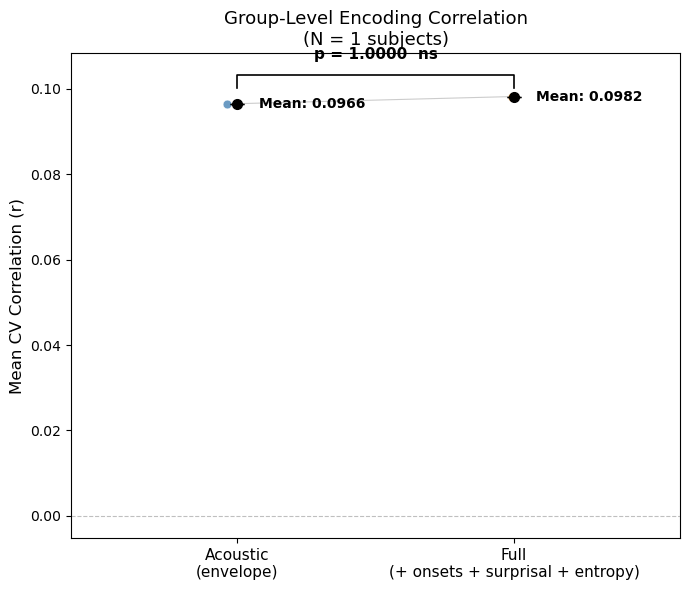

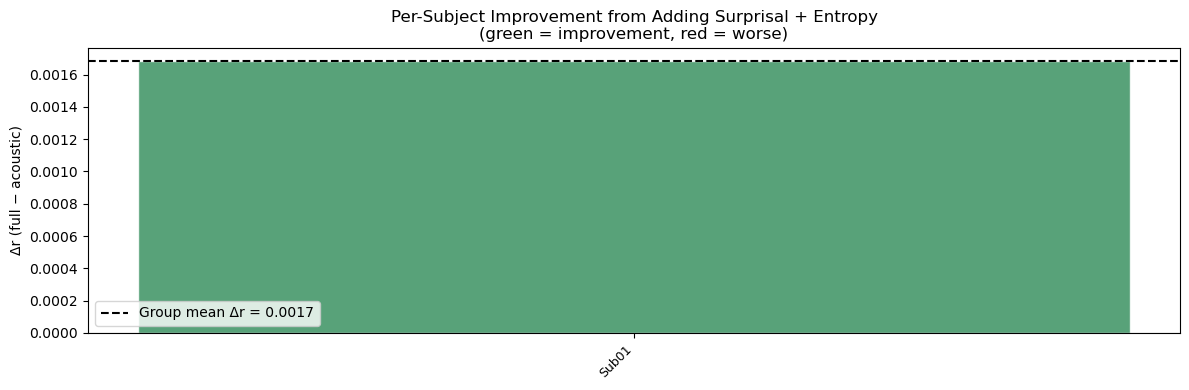

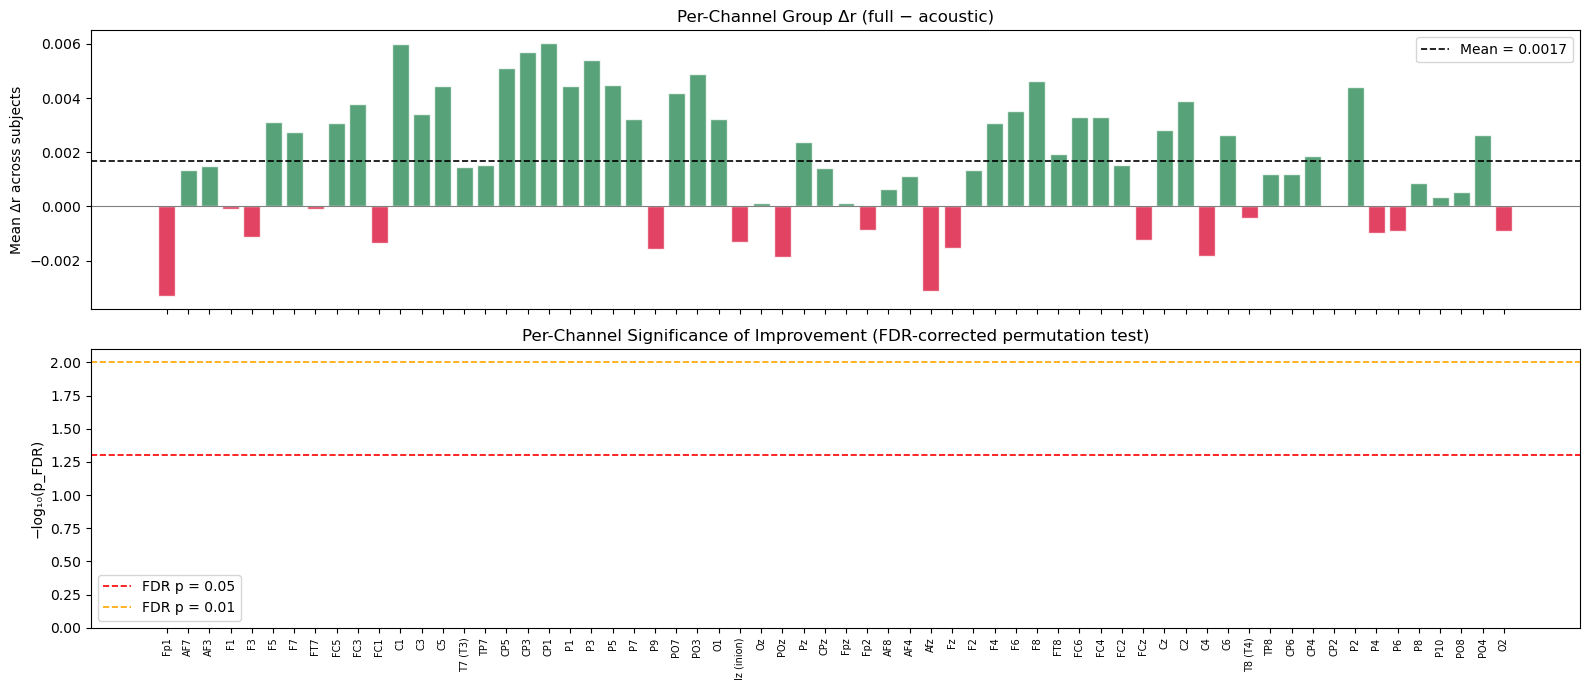

In [30]:
n_subjects = 1
pickle_folder = 'encoding_2026-07-06'
model = 'sklearn_ridge'

plot(n_subjects, pickle_folder, model)

  Sub01 loaded

Loaded 1 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 1.0000  ns
  Mean Δr = -0.0005 ± 0.0000 SEM
  Channels significant after FDR (p<0.05): 0 / 64


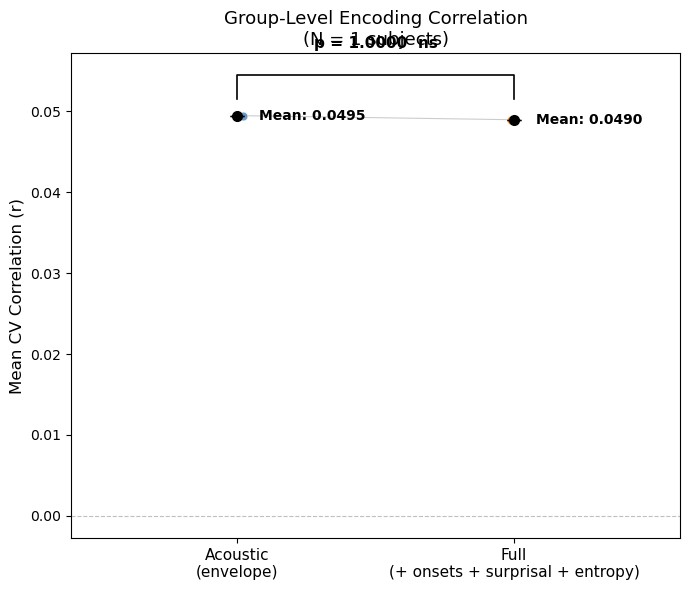

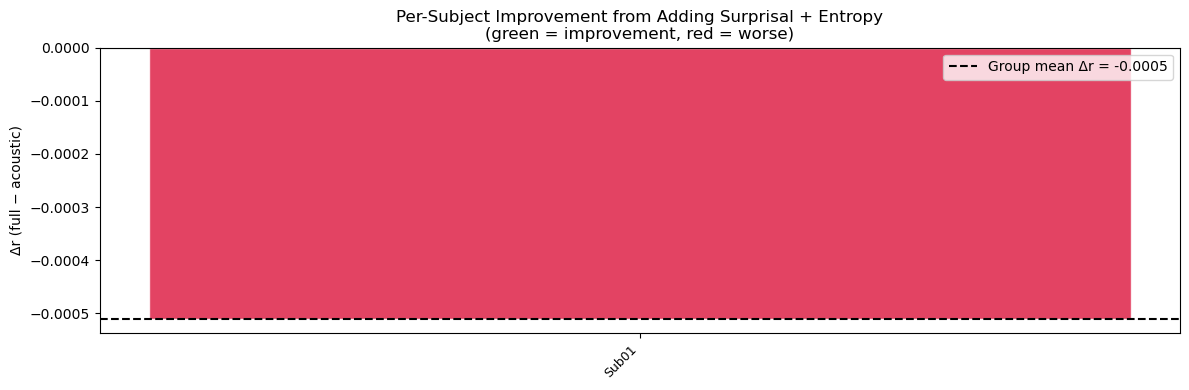

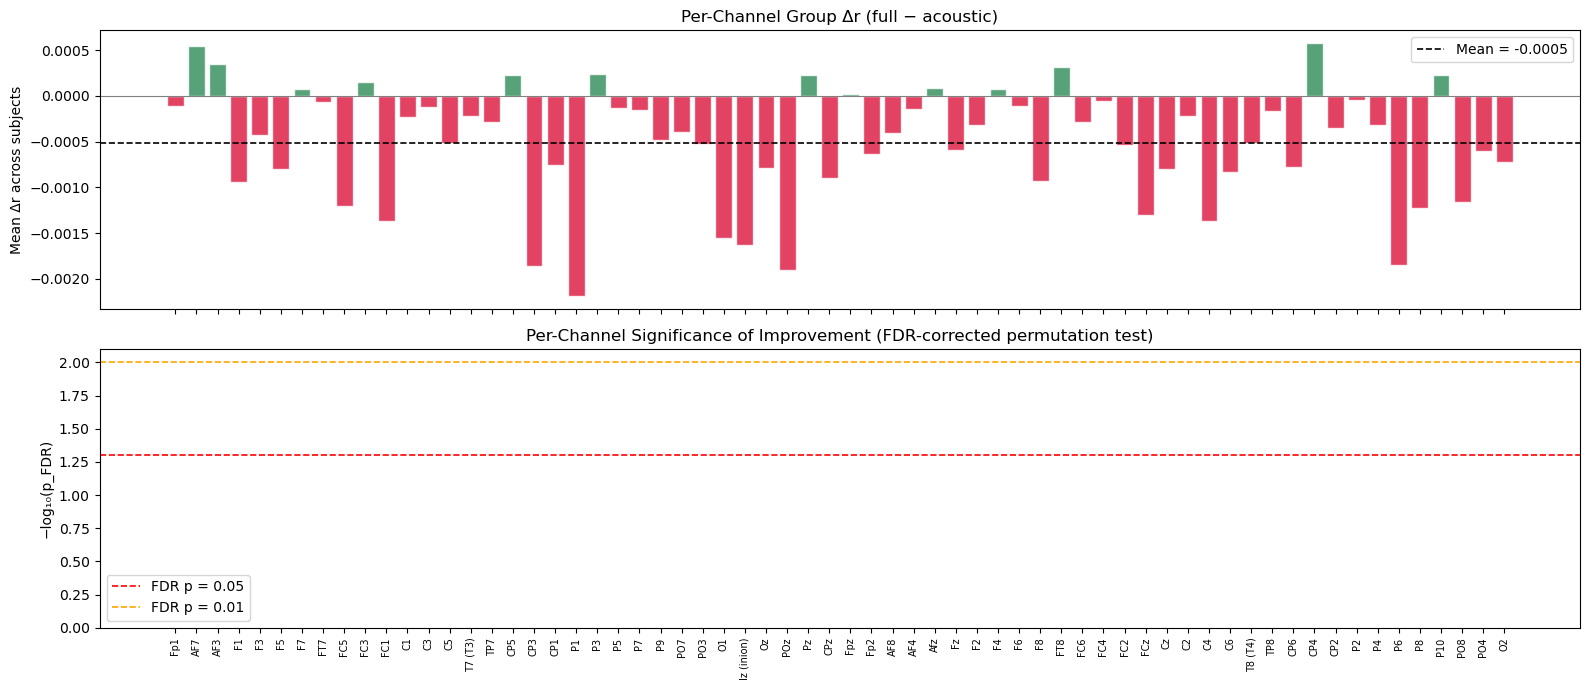

In [31]:
n_subjects = 1
pickle_folder = 'encoding_2026-07-06'
model = 'boosting'

plot(n_subjects, pickle_folder, model)

  Sub01 loaded

Loaded 1 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 1.0000  ns
  Mean Δr = -0.0588 ± 0.0000 SEM
  Channels significant after FDR (p<0.05): 0 / 64


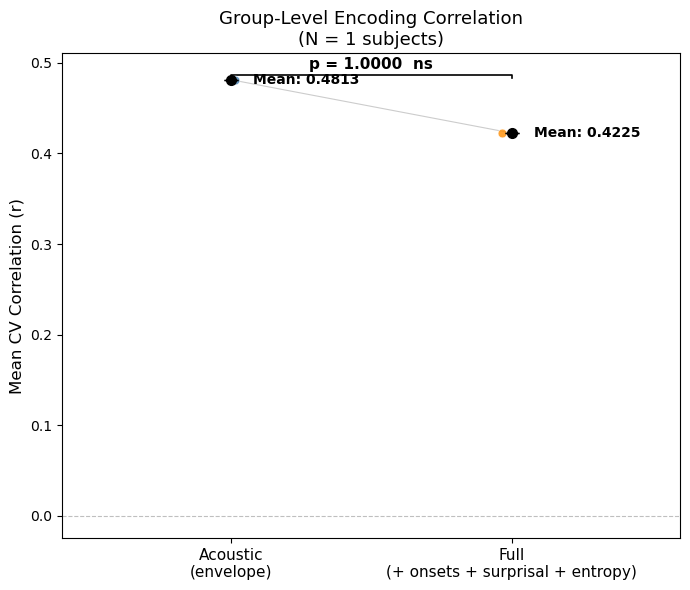

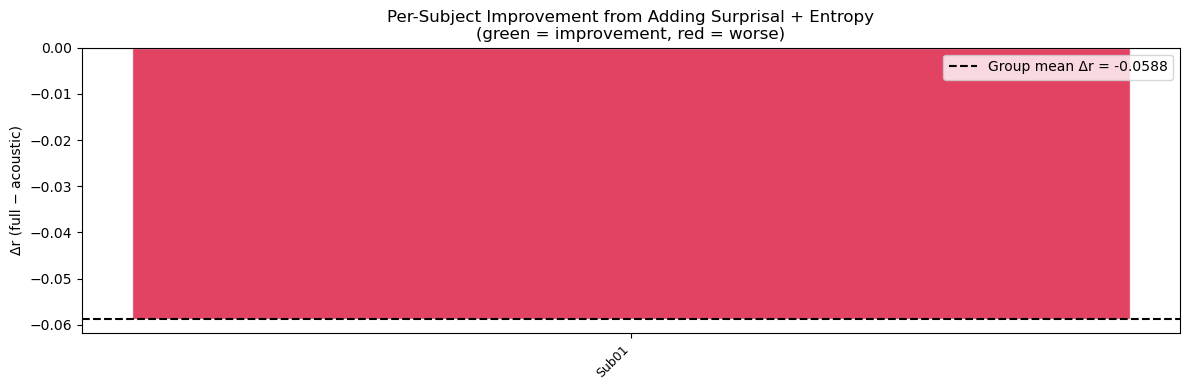

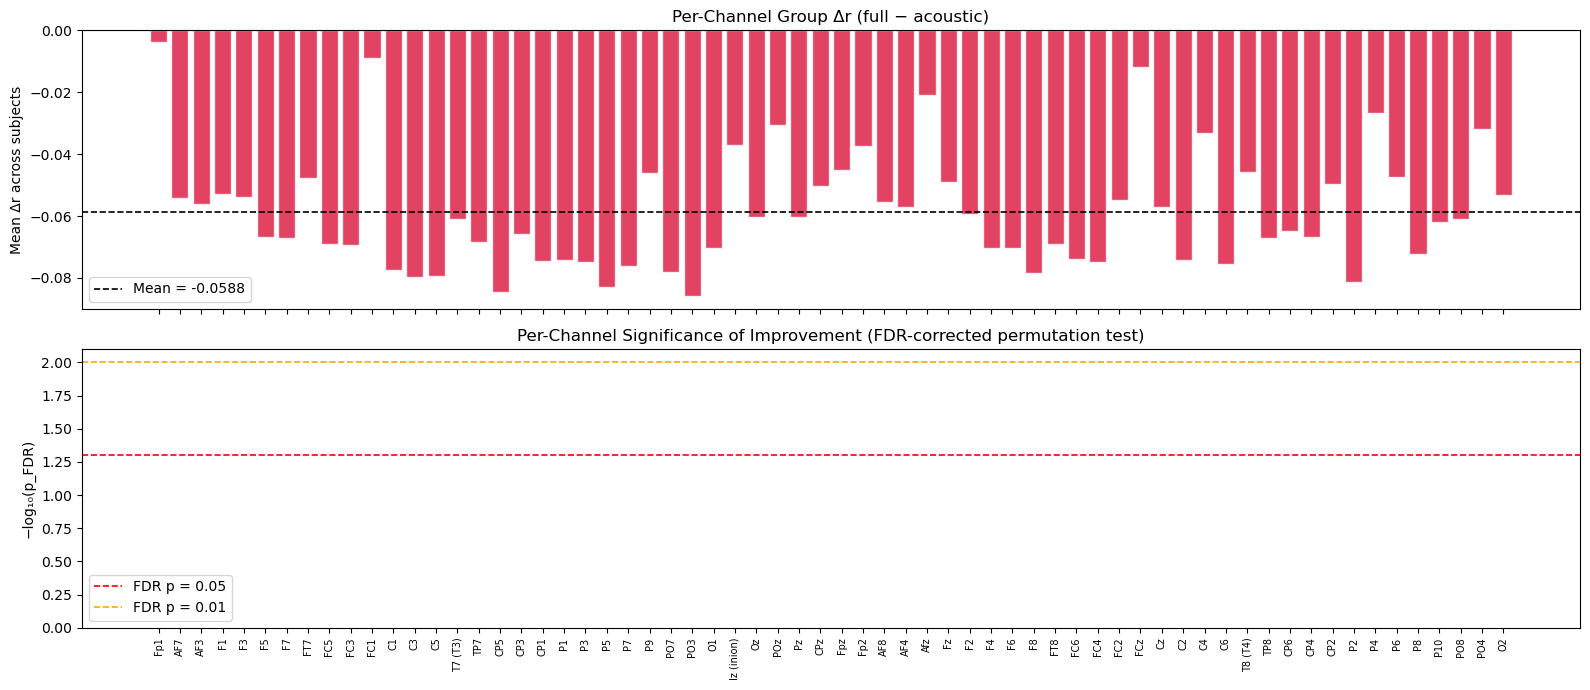

In [35]:
n_subjects = 1
pickle_folder = 'encoding_2026-07-06'
model = 'conv_nonlinear'

plot(n_subjects, pickle_folder, model)

  Sub01 loaded

Loaded 1 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 1.0000  ns
  Mean Δr = 0.0023 ± 0.0000 SEM
  Channels significant after FDR (p<0.05): 0 / 64


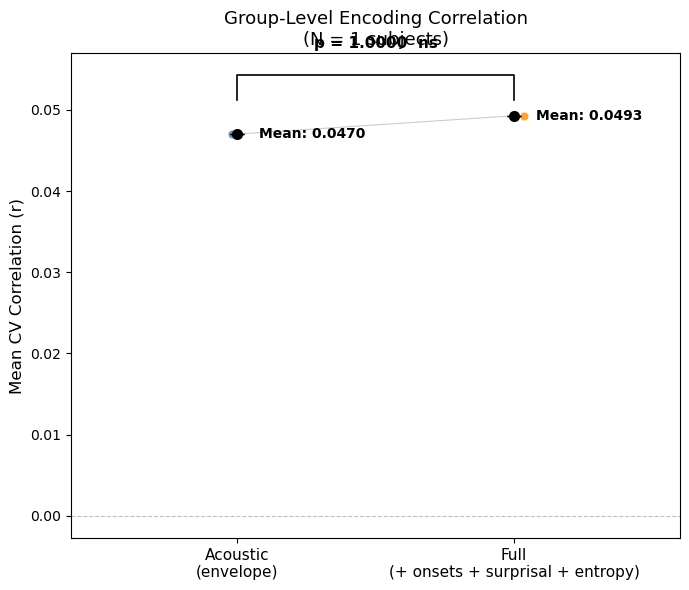

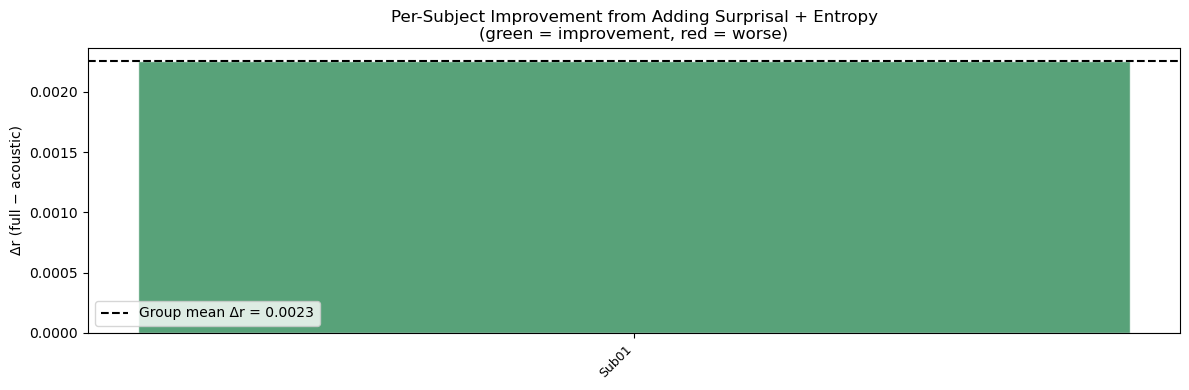

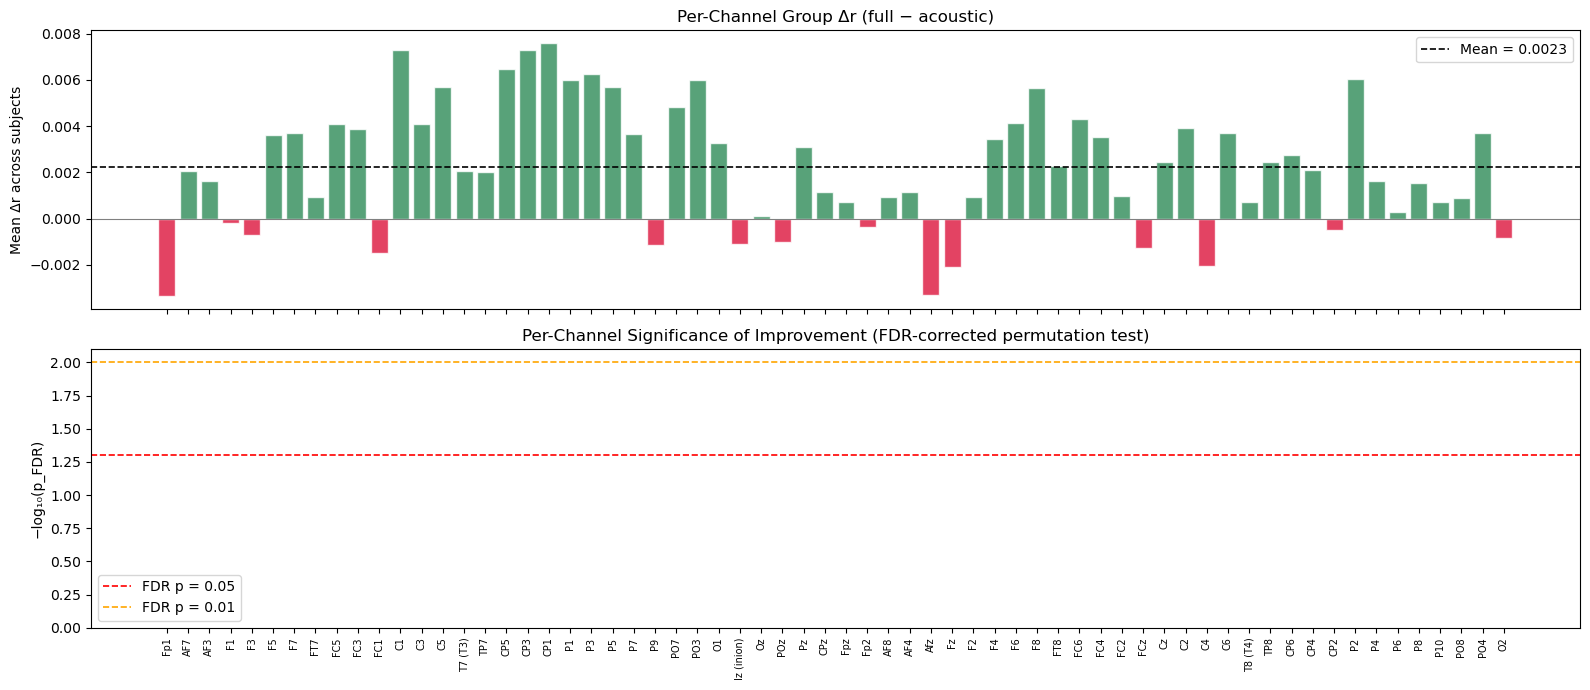

In [40]:
n_subjects = 1
pickle_folder = 'encoding_2026-07-06'
model = 'mne_ridge'

plot(n_subjects, pickle_folder, model)

In [36]:
def plot_across_models(n_subjects=None, pickle_folder=None, models=None):
    """
    Create a single figure showing side-by-side violins of mean CV correlation
    (acoustic vs full) for multiple models.
    """
    if n_subjects is None:
        n_subjects = globals().get('n_subjects', 1)
    if pickle_folder is None:
        pickle_folder = globals().get('pickle_folder', '')
    if models is None:
        models = ['boosting', 'sklearn_ridge', 'mne_ridge', 'conv_nonlinear']

    colors = ['steelblue', 'darkorange']
    fig, ax = plt.subplots(figsize=(12, 6))

    spacing = 3
    centers = []
    legend_handles = [
        Patch(facecolor=colors[0], edgecolor='none', label='Acoustic (envelope)'),
        Patch(facecolor=colors[1], edgecolor='none', label='Full (+ onsets + surprisal + entropy)')
    ]

    for i, model_name in enumerate(models):
        r_acoustic_all = []
        r_full_all = []

        for sub in range(1, n_subjects + 1):
            try:
                a = eelbrain.load.unpickle(f"../pickles/{pickle_folder}/Sub{sub}__{model_name}__acoustic.pkl")
                f = eelbrain.load.unpickle(f"../pickles/{pickle_folder}/Sub{sub}__{model_name}__acoustic_and_surprisal.pkl")
                r_acoustic_all.append(a['r_per_channel'])
                r_full_all.append(f['r_per_channel'])
            except FileNotFoundError:
                # skip missing subjects for this model
                continue

        if len(r_acoustic_all) == 0:
            continue

        r_acoustic_all = np.array(r_acoustic_all)
        r_full_all = np.array(r_full_all)
        r_acoustic_per_sub = r_acoustic_all.mean(axis=1)
        r_full_per_sub = r_full_all.mean(axis=1)

        base = i * spacing
        pos = [base + 1, base + 2]
        centers.append((pos[0] + pos[1]) / 2)

        parts = ax.violinplot([r_acoustic_per_sub, r_full_per_sub],
                              positions=pos, showmedians=False, showextrema=False)
        for pc, color in zip(parts['bodies'], colors):
            pc.set_facecolor(color)
            pc.set_alpha(0.6)

        # connect paired subject points within this model
        for j in range(len(r_acoustic_per_sub)):
            ax.plot([pos[0], pos[1]],
                    [r_acoustic_per_sub[j], r_full_per_sub[j]],
                    color='gray', alpha=0.4, linewidth=0.7)

        # scatter with jitter
        jitter = np.random.uniform(-0.04, 0.04, size=len(r_acoustic_per_sub))
        ax.scatter(np.full(len(r_acoustic_per_sub), pos[0]) + jitter, r_acoustic_per_sub,
                   color=colors[0], edgecolors='white', linewidths=0.5, s=40, alpha=0.8, zorder=4)
        jitter = np.random.uniform(-0.04, 0.04, size=len(r_full_per_sub))
        ax.scatter(np.full(len(r_full_per_sub), pos[1]) + jitter, r_full_per_sub,
                   color=colors[1], edgecolors='white', linewidths=0.5, s=40, alpha=0.8, zorder=4)

        # mean ± SEM markers
        for k, d in enumerate([r_acoustic_per_sub, r_full_per_sub], start=0):
            mean_val = d.mean()
            sem = d.std() / np.sqrt(len(d))
            ax.errorbar(pos[k], mean_val, yerr=sem, fmt='o', color='black',
                        markersize=6, capsize=4, linewidth=1.5, zorder=5)

        # optional: compute and display p-value for this model
        try:
            mean_diff, p_val = permutation_test(r_acoustic_per_sub, r_full_per_sub,
                                                n_permutations=10000, two_tailed=True)
            sig_label = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
            y_bracket = max(r_acoustic_per_sub.max(), r_full_per_sub.max()) + 0.005
            ax.plot([pos[0], pos[0], pos[1], pos[1]],
                    [y_bracket - 0.003, y_bracket, y_bracket, y_bracket - 0.003],
                    color='black', linewidth=1.0)
            ax.text((pos[0] + pos[1]) / 2, y_bracket + 0.003, f'p={p_val:.3f} {sig_label}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        except Exception:
            pass

    ax.set_xticks(centers)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_xlim(-0.5, spacing * len(models) - 0.5)
    ax.set_ylabel('Mean CV Correlation (r)', fontsize=12)
    ax.set_title(f'Comparison across models (N subjects per model shown)', fontsize=13)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

    ax.legend(handles=legend_handles, loc='upper left')
    plt.tight_layout()
    plt.show()

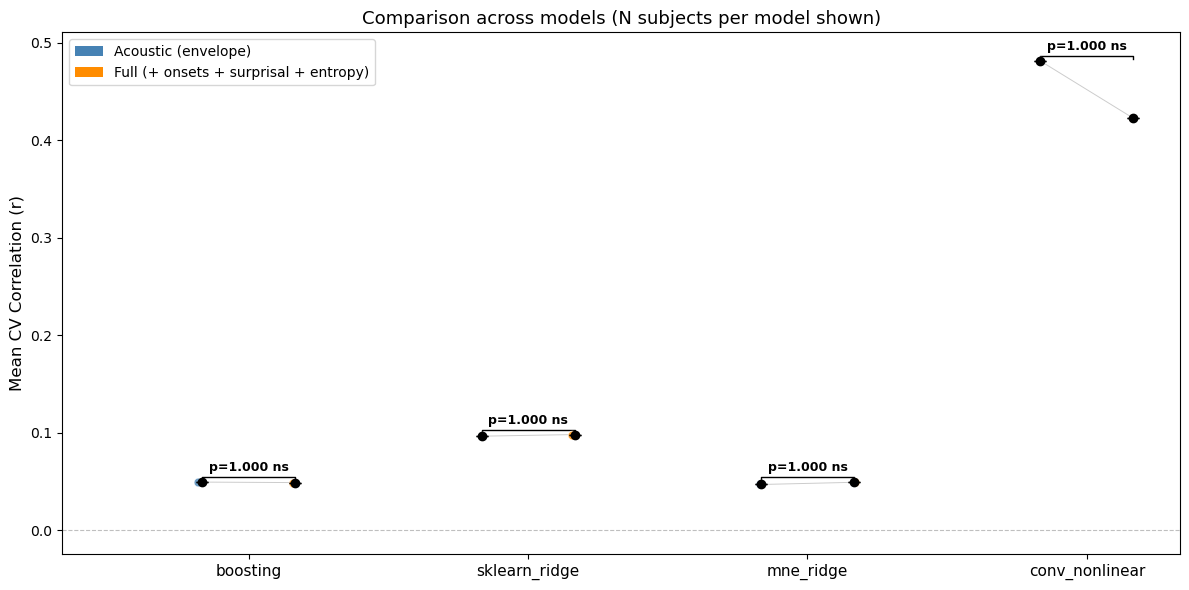

In [39]:
n_subjects = 1
pickle_folder = 'encoding_2026-07-06'

plot_across_models(n_subjects=n_subjects, pickle_folder=pickle_folder, models=None)